# Verify Blatter et al. (2023) RNA-Cyp33-MLL1 switch

This notebook verifies the curated BNGL model against BioNetGen reference output, an independent SciPy integration of the generated reaction network, and digitized Fig. 5B traces from Blatter et al. (2023).

In [1]:
from pathlib import Path
import math
import os
import re
import shutil
import subprocess
import tempfile

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-bngl-models"))
import matplotlib.pyplot as plt

MODEL_DIR = Path.cwd()
BNGL_FILE = MODEL_DIR / "rna_induced_cyp33_mll1_repression_blatter2023.bngl"
REF_DIR = MODEL_DIR / "reference"
STEM = "rna_induced_cyp33_mll1_repression_blatter2023"
VERIFY_PNG = MODEL_DIR / "verify_blatter2023.png"

assert BNGL_FILE.exists()
assert REF_DIR.exists()


Matplotlib is building the font cache; this may take a moment.


In [2]:
def read_bng_table(path: Path) -> pd.DataFrame:
    columns = path.read_text().splitlines()[0].split()[1:]
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None)
    df.columns = columns
    return df


def normalized_net_text(path: Path) -> str:
    lines = []
    for line in path.read_text().splitlines():
        stripped = line.strip()
        if stripped and not stripped.startswith("#"):
            lines.append(" ".join(stripped.split()))
    return "\n".join(lines)


def numeric_max_errors(a: pd.DataFrame, b: pd.DataFrame) -> dict[str, float]:
    shared = [c for c in a.columns if c in b.columns]
    max_abs = 0.0
    max_rel_or_abs = 0.0
    for col in shared:
        av = a[col].to_numpy(dtype=float)
        bv = b[col].to_numpy(dtype=float)
        abs_err = np.abs(av - bv)
        scale = max(np.max(np.abs(av)), np.max(np.abs(bv)), 1.0)
        denom = np.maximum(np.abs(av), np.abs(bv))
        rel_or_abs = abs_err / scale
        np.divide(abs_err, denom, out=rel_or_abs, where=denom > 1e-9)
        max_abs = max(max_abs, float(abs_err.max()))
        max_rel_or_abs = max(max_rel_or_abs, float(rel_or_abs.max()))
    return {"max_abs": max_abs, "max_rel_or_abs": max_rel_or_abs}


In [3]:
run_dir = Path(tempfile.mkdtemp(prefix="verify_blatter2023_bng_"))
bng_exe = shutil.which("bionetgen")
if bng_exe is None:
    raise RuntimeError("BioNetGen executable not found on PATH")

completed = subprocess.run(
    [bng_exe, "run", "-i", str(BNGL_FILE), "-o", str(run_dir)],
    cwd=MODEL_DIR,
    text=True,
    capture_output=True,
    check=True,
)
print(f"BioNetGen run directory: {run_dir}")
print("BioNetGen stderr first line:", completed.stderr.splitlines()[0] if completed.stderr else "")

generated = {
    "net": run_dir / f"{STEM}.net",
    "ode_net": run_dir / f"{STEM}_ode.net",
    "gdat": run_dir / f"{STEM}_ode.gdat",
    "cdat": run_dir / f"{STEM}_ode.cdat",
}
for path in generated.values():
    assert path.exists(), path


BioNetGen run directory: /var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000bmg/T/verify_blatter2023_bng_s8yn2nwa
BioNetGen stderr first line: /Users/wish/Code/BNGL-Models/.venv/lib/python3.12/site-packages/bionetgen/main.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [4]:
reference_check = pd.DataFrame([
    {
        "file": f"{STEM}.net",
        "match": normalized_net_text(generated["net"]) == normalized_net_text(REF_DIR / f"{STEM}.net"),
        "max_rel_or_abs": 0.0,
        "max_abs": 0.0,
    },
    {
        "file": f"{STEM}_ode.net",
        "match": normalized_net_text(generated["ode_net"]) == normalized_net_text(REF_DIR / f"{STEM}_ode.net"),
        "max_rel_or_abs": 0.0,
        "max_abs": 0.0,
    },
])

for kind in ["gdat", "cdat"]:
    gen = read_bng_table(generated[kind])
    ref = read_bng_table(REF_DIR / f"{STEM}_ode.{kind}")
    err = numeric_max_errors(gen, ref)
    reference_check = pd.concat([
        reference_check,
        pd.DataFrame([{
            "file": f"{STEM}_ode.{kind}",
            "match": err["max_rel_or_abs"] <= 1e-12,
            **err,
        }]),
    ], ignore_index=True)

reference_check


,file,match,max_rel_or_abs,max_abs
0,rna_induced_cyp33_mll1_repression_blatter2023.net,True,0.0,0.0
1,rna_induced_cyp33_mll1_repression_blatter2023_...,True,0.0,0.0
2,rna_induced_cyp33_mll1_repression_blatter2023_...,True,0.0,0.0
3,rna_induced_cyp33_mll1_repression_blatter2023_...,True,0.0,0.0


In [5]:
def parse_net(path: Path):
    text = path.read_text()

    def block(name: str) -> str:
        return re.search(rf"begin {name}\n(.*?)end {name}", text, re.S).group(1)

    params: dict[str, float] = {}
    for line in block("parameters").splitlines():
        parts = line.split("#", 1)[0].split()
        if len(parts) >= 3:
            name = parts[1]
            expr = "".join(parts[2:])
            params[name] = float(eval(expr, {"__builtins__": {}}, params))

    functions: dict[str, str] = {}
    for line in block("functions").splitlines():
        parts = line.strip().split(None, 2)
        if len(parts) == 3:
            functions[parts[1].replace("()", "")] = parts[2]

    species_names: list[str] = []
    y0: list[float] = []
    for line in block("species").splitlines():
        parts = line.split("#", 1)[0].split()
        if len(parts) >= 3:
            species_names.append(parts[1])
            y0.append(float(eval("".join(parts[2:]), {"__builtins__": {}}, params)))

    reactions = []
    for line in block("reactions").splitlines():
        raw = line.split("#", 1)[0].strip()
        if not raw:
            continue
        parts = raw.split()
        reactants = [] if parts[1] == "0" else [int(x) - 1 for x in parts[1].split(",")]
        products = [] if parts[2] == "0" else [int(x) - 1 for x in parts[2].split(",")]
        reactions.append((reactants, products, parts[3]))

    groups = {}
    for line in block("groups").splitlines():
        parts = line.strip().split(None, 2)
        if len(parts) >= 3:
            groups[parts[1]] = [int(x) - 1 for x in parts[2].replace(" ", "").split(",")]

    return params, functions, species_names, np.array(y0, dtype=float), reactions, groups


params, functions, species_names, y0, reactions, groups = parse_net(REF_DIR / f"{STEM}.net")
print(len(species_names), "species", len(reactions), "unidirectional reactions")


16 species 45 unidirectional reactions


In [6]:
def make_rhs(base_params, functions, reactions, groups, phase_changes):
    p = base_params.copy()
    p.update(phase_changes)

    def eval_rate(rate_name: str, y: np.ndarray, obs: dict[str, float]) -> float:
        env = {**p, **obs}
        if rate_name in functions:
            return float(eval(functions[rate_name], {"__builtins__": {}}, env))
        return float(eval(rate_name, {"__builtins__": {}}, env))

    def rhs(t: float, y: np.ndarray) -> np.ndarray:
        y_pos = np.maximum(y, 0.0)
        obs = {name: float(y_pos[idxs].sum()) for name, idxs in groups.items()}
        dy = np.zeros_like(y_pos)
        for reactants, products, rate_name in reactions:
            rate = eval_rate(rate_name, y_pos, obs)
            for idx in reactants:
                rate *= y_pos[idx]
            for idx in reactants:
                dy[idx] -= rate
            for idx in products:
                dy[idx] += rate
        return dy

    return rhs


def integrate_independent(t_eval: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    phases = [
        (0.0, 336.0, {"ksyn_RNA": 0.0, "ksyn_Cyp33": 0.0, "input_on": 0.0}),
        (336.0, 1320.0, {"ksyn_RNA": 1.5, "ksyn_Cyp33": 1.5, "input_on": 1.0}),
        (1320.0, 1920.0, {"ksyn_RNA": 0.0, "ksyn_Cyp33": 0.0, "input_on": 0.1}),
    ]
    y_current = y0.copy()
    all_t = []
    all_y = []
    for start, end, changes in phases:
        mask = (t_eval >= start - 1e-9) & (t_eval <= end + 1e-9)
        t_phase = t_eval[mask]
        sol = solve_ivp(
            make_rhs(params, functions, reactions, groups, changes),
            (start, end),
            y_current,
            method="LSODA",
            t_eval=t_phase,
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(sol.message)
        if all_t and abs(sol.t[0] - all_t[-1]) < 1e-9:
            all_t.extend(sol.t[1:])
            all_y.append(sol.y[:, 1:])
        else:
            all_t.extend(sol.t)
            all_y.append(sol.y)
        y_current = sol.y[:, -1]
    return np.array(all_t), np.hstack(all_y).T

bng = read_bng_table(generated["gdat"])
t_ind, y_ind = integrate_independent(bng["time"].to_numpy())
assert np.max(np.abs(t_ind - bng["time"].to_numpy())) <= 1e-12

independent_curves = pd.DataFrame({"time": t_ind})
for name, idxs in groups.items():
    independent_curves[name] = y_ind[:, idxs].sum(axis=1)

independent_rows = []
for name in groups:
    pred = independent_curves[name].to_numpy()
    obs = bng[name].to_numpy()
    abs_err = np.abs(pred - obs)
    denom = np.maximum(np.abs(pred), np.abs(obs))
    rel_or_abs = abs_err.copy()
    np.divide(abs_err, denom, out=rel_or_abs, where=denom > 1e-7)
    independent_rows.append({
        "observable": name,
        "max_abs": float(abs_err.max()),
        "max_rel_or_abs": float(rel_or_abs.max()),
    })

independent_check = pd.DataFrame(independent_rows).sort_values("max_rel_or_abs", ascending=False)
independent_check.head(10)


,observable,max_abs,max_rel_or_abs
7,Obs_Cyp33_MLL1,1.058126e-06,2.616917e-07
16,Obs_Cyp33_ParallelA3,7.146609e-07,2.499011e-07
13,Obs_Cyp33_FreeA3,2.696256e-07,2.404445e-07
2,Obs_Tot_Cyp33,1.104731e-06,2.314674e-07
3,Obs_Tot_RNA,1.280933e-06,2.271747e-07
8,Obs_Cyp33_MLL1_H3K4me3,5.053176e-07,2.207233e-07
15,Obs_Cyp33_A2A3,3.285639e-07,2.205273e-07
14,Obs_Cyp33_PerpA3,5.764894e-07,2.205127e-07
9,Obs_RNA_H3K4me3,8.885459e-07,2.018983e-07
5,Obs_Repressive_H3K4me3,1.556734e-06,6.929309e-08


In [7]:
reported = pd.read_csv(REF_DIR / "blatter2023_fig5b_digitized.csv")
reported_map = {
    "reported_active_h3k4me3": "Obs_Active_H3K4me3",
    "reported_repressive_h3k4me3": "Obs_Repressive_H3K4me3",
    "reported_rna_total": "Obs_Tot_RNA",
    "reported_mll1_h3k4me3": "Obs_MLL1_H3K4me3",
    "reported_cyp33_mll1": "Obs_Cyp33_MLL1",
    "reported_cyp33_mll1_h3k4me3": "Obs_Cyp33_MLL1_H3K4me3",
    "reported_rna_h3k4me3": "Obs_RNA_H3K4me3",
    "reported_free_h3k4me3": "Obs_Free_H3K4me3",
}

bng_plot = bng.copy()
bng_plot["time_min"] = bng_plot["time"] / 60.0
reported_rows = []
for curve, obs_name in reported_map.items():
    d = reported[reported["curve"] == curve].copy()
    d = d[(d["value_uM"] >= -5.0) & (d["value_uM"] <= 112.0)]
    # Exclude the rendered vertical strokes at staged parameter changes; those
    # pixels represent discontinuity thickness, not a single-valued trajectory.
    keep = ~(
        ((d["time_min"] >= 5.3) & (d["time_min"] <= 6.4))
        | ((d["time_min"] >= 21.8) & (d["time_min"] <= 22.6))
    )
    d = d[keep]
    model_values = np.interp(d["time_min"], bng_plot["time_min"], bng_plot[obs_name])
    err = np.abs(model_values - d["value_uM"].to_numpy(dtype=float))
    reported_rows.append({
        "curve": curve,
        "observable": obs_name,
        "n_points": int(len(d)),
        "median_abs_error_uM": float(np.median(err)),
        "p95_abs_error_uM": float(np.percentile(err, 95)),
        "max_abs_error_uM": float(np.max(err)),
    })

reported_check = pd.DataFrame(reported_rows).sort_values("p95_abs_error_uM", ascending=False)
reported_check


,curve,observable,n_points,median_abs_error_uM,p95_abs_error_uM,max_abs_error_uM
4,reported_cyp33_mll1,Obs_Cyp33_MLL1,253,6.595527,6.749492,6.753719
6,reported_rna_h3k4me3,Obs_RNA_H3K4me3,201,0.522819,6.587810,20.833571
1,reported_repressive_h3k4me3,Obs_Repressive_H3K4me3,328,0.857336,5.538227,6.173489
0,reported_active_h3k4me3,Obs_Active_H3K4me3,330,1.160394,5.228877,5.911427
2,reported_rna_total,Obs_Tot_RNA,330,0.113536,4.868231,14.697959
3,reported_mll1_h3k4me3,Obs_MLL1_H3K4me3,327,3.891038,4.345937,4.812771
7,reported_free_h3k4me3,Obs_Free_H3K4me3,327,0.166626,4.144901,4.829378
5,reported_cyp33_mll1_h3k4me3,Obs_Cyp33_MLL1_H3K4me3,228,2.825426,2.926866,3.169996


In [8]:
assert reference_check["match"].all()
assert independent_check["max_abs"].max() <= 2e-5
assert independent_check["max_rel_or_abs"].max() <= 2e-2
assert reported_check["median_abs_error_uM"].max() <= 7.0
assert reported_check["p95_abs_error_uM"].max() <= 8.0

print("Reference regeneration max error:")
print(reference_check[["file", "max_abs", "max_rel_or_abs"]].to_string(index=False))
print("\nIndependent SciPy max abs error:", independent_check["max_abs"].max())
print("Reported Fig. 5B max p95 abs error (uM):", reported_check["p95_abs_error_uM"].max())


Reference regeneration max error:
                                                  file  max_abs  max_rel_or_abs
     rna_induced_cyp33_mll1_repression_blatter2023.net      0.0             0.0
 rna_induced_cyp33_mll1_repression_blatter2023_ode.net      0.0             0.0
rna_induced_cyp33_mll1_repression_blatter2023_ode.gdat      0.0             0.0
rna_induced_cyp33_mll1_repression_blatter2023_ode.cdat      0.0             0.0

Independent SciPy max abs error: 2.598173836076967e-06
Reported Fig. 5B max p95 abs error (uM): 6.7494916153436435


PosixPath('/Users/wish/Code/BNGL-Models/models/rna_induced_cyp33_mll1_repression_blatter2023/verify_blatter2023.png')

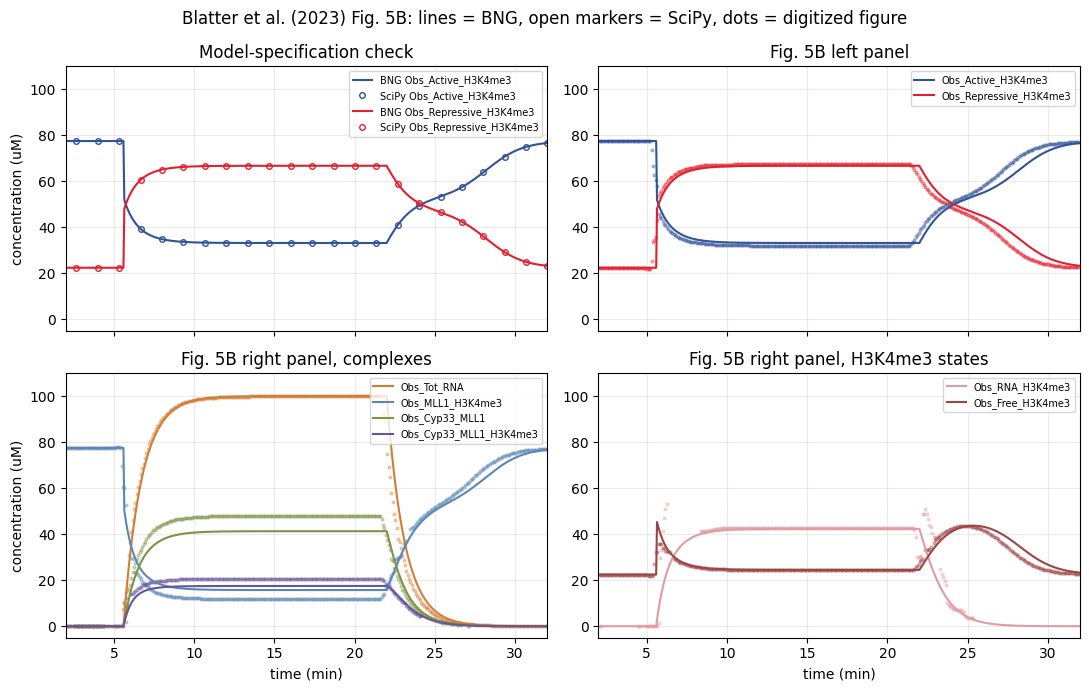

In [9]:
colors = {
    "Obs_Active_H3K4me3": "#315398",
    "Obs_Repressive_H3K4me3": "#e31f2f",
    "Obs_Tot_RNA": "#d27d34",
    "Obs_MLL1_H3K4me3": "#5a86b8",
    "Obs_Cyp33_MLL1": "#7b9445",
    "Obs_Cyp33_MLL1_H3K4me3": "#67559a",
    "Obs_RNA_H3K4me3": "#df9ca2",
    "Obs_Free_H3K4me3": "#9d4545",
}
curve_colors = {curve: colors[obs] for curve, obs in reported_map.items()}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
ax = axes[0, 0]
for obs in ["Obs_Active_H3K4me3", "Obs_Repressive_H3K4me3"]:
    ax.plot(bng_plot["time_min"], bng_plot[obs], color=colors[obs], lw=1.5, label=f"BNG {obs}")
    ax.plot(
        independent_curves["time"] / 60.0,
        independent_curves[obs],
        "o",
        mfc="none",
        mec=colors[obs],
        ms=4,
        markevery=25,
        label=f"SciPy {obs}",
    )
ax.set_title("Model-specification check")
ax.set_ylabel("concentration (uM)")
ax.legend(fontsize=7)

ax = axes[0, 1]
for curve in ["reported_active_h3k4me3", "reported_repressive_h3k4me3"]:
    obs = reported_map[curve]
    d = reported[reported["curve"] == curve]
    ax.scatter(d["time_min"], d["value_uM"], s=4, color=curve_colors[curve], alpha=0.35)
    ax.plot(bng_plot["time_min"], bng_plot[obs], color=colors[obs], lw=1.5, label=obs)
ax.set_title("Fig. 5B left panel")
ax.legend(fontsize=7)

ax = axes[1, 0]
right_curves = [
    "reported_rna_total",
    "reported_mll1_h3k4me3",
    "reported_cyp33_mll1",
    "reported_cyp33_mll1_h3k4me3",
]
for curve in right_curves:
    obs = reported_map[curve]
    d = reported[reported["curve"] == curve]
    ax.scatter(d["time_min"], d["value_uM"], s=4, color=curve_colors[curve], alpha=0.35)
    ax.plot(bng_plot["time_min"], bng_plot[obs], color=colors[obs], lw=1.5, label=obs)
ax.set_title("Fig. 5B right panel, complexes")
ax.set_ylabel("concentration (uM)")
ax.set_xlabel("time (min)")
ax.legend(fontsize=7)

ax = axes[1, 1]
for curve in ["reported_rna_h3k4me3", "reported_free_h3k4me3"]:
    obs = reported_map[curve]
    d = reported[reported["curve"] == curve]
    ax.scatter(d["time_min"], d["value_uM"], s=4, color=curve_colors[curve], alpha=0.35)
    ax.plot(bng_plot["time_min"], bng_plot[obs], color=colors[obs], lw=1.5, label=obs)
ax.set_title("Fig. 5B right panel, H3K4me3 states")
ax.set_xlabel("time (min)")
ax.legend(fontsize=7)

for ax in axes.flat:
    ax.set_xlim(2, 32)
    ax.set_ylim(-5, 110)
    ax.grid(alpha=0.25)

fig.suptitle("Blatter et al. (2023) Fig. 5B: lines = BNG, open markers = SciPy, dots = digitized figure")
fig.tight_layout()
fig.savefig(VERIFY_PNG, dpi=200)
VERIFY_PNG
